In [64]:
# Import essential data manipulation libraries
import pandas as pd  # For data processing and manipulation
import numpy as np   # For numerical operations and array handling

# Import visualization libraries
import matplotlib.pyplot as plt  # Basic plotting library
import seaborn as sns            # Statistical data visualization
import plotly.express as px      # Interactive visualization library

In [65]:
# Load the Netflix dataset from a CSV file into a pandas DataFrame
# This dataset contains information about Netflix movies and TV shows for clustering analysis
netflix_data=pd.read_csv("C:/Users/Dell/Downloads/NETFLIX MOVIES AND TV SHOWS CLUSTERING.CSV")

In [66]:
# Display the first 5 rows of the netflix_data DataFrame to get a quick overview of its structure and content
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [67]:
# Print the number of rows in the netflix_data DataFrame
print("Rows:",netflix_data.shape[0])
# Print the number of columns in the netflix_data DataFrame
print("Columns:", netflix_data.shape[1])

Rows: 7787
Columns: 12


In [68]:
# Display information about the netflix_data DataFrame
# This shows the number of rows, columns, column names, data types, and memory usage
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [69]:
# Check for duplicate rows in the netflix_data DataFrame and print the total count
print('Number of duplicates in dataset:',netflix_data.duplicated().sum())

Number of duplicates in dataset: 0


In [70]:
# Create a DataFrame to analyze missing values in the netflix_data DataFrame
missing_values=pd.DataFrame({
    # Count the number of null values in each column
    "missing_values": netflix_data.isnull().sum(),
    # Calculate the percentage of missing values in each column
    "percentage(%)": netflix_data.isnull().mean()*100
}).sort_values("missing_values", ascending=False)  # Sort by missing values in descending order

# Display the missing values analysis
print(missing_values)

              missing_values  percentage(%)
director                2389      30.679337
cast                     718       9.220496
country                  507       6.510851
date_added                10       0.128419
rating                     7       0.089893
title                      0       0.000000
show_id                    0       0.000000
type                       0       0.000000
release_year               0       0.000000
duration                   0       0.000000
listed_in                  0       0.000000
description                0       0.000000


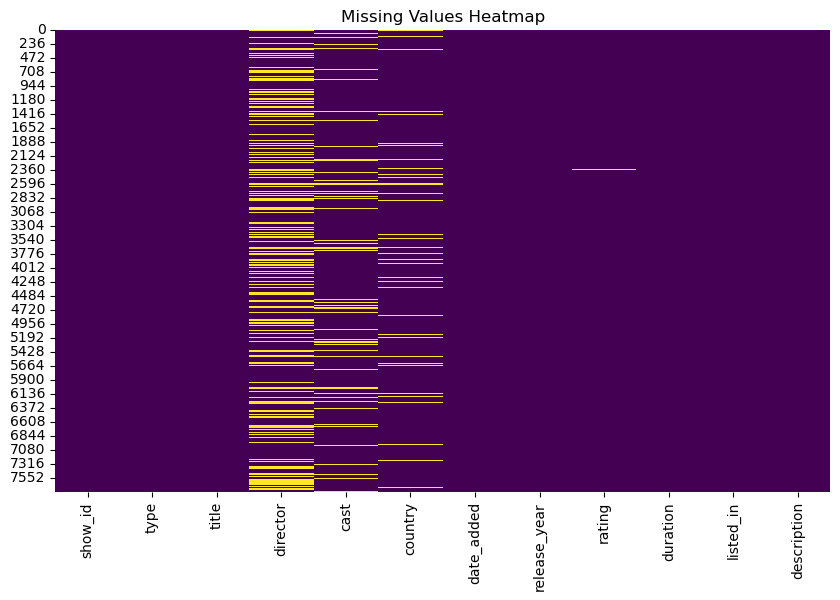

In [71]:
# Create a figure with specified size (10x6 inches)
plt.figure(figsize=(10,6))
# Generate a heatmap showing missing values in the netflix_data DataFrame
# True values (missing data) will be highlighted, False values (existing data) will be dark
# cbar=False removes the color bar, cmap='viridis' sets the color scheme
sns.heatmap(netflix_data.isnull(),cbar=False,cmap='viridis')
# Add a title to the heatmap
plt.title("Missing Values Heatmap")
# Display the plot
plt.show()

In [72]:
# Get a list of all column names in the netflix_data DataFrame
netflix_data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [73]:
# Generate descriptive statistics for the netflix_data DataFrame
# This includes count, mean, std, min, 25%, 50%, 75%, max for numeric columns
netflix_data.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [74]:
# Count the number of unique values in each column of the netflix_data DataFrame
# This helps understand the cardinality of each feature in the dataset
netflix_data.nunique()

show_id         7787
type               2
title           7787
director        4049
cast            6831
country          681
date_added      1565
release_year      73
rating            14
duration         216
listed_in        492
description     7769
dtype: int64

In [75]:
# Create a copy of the netflix_data DataFrame to preserve the original data
# while allowing modifications to the copy
netflix_data_copy=netflix_data.copy()

In [76]:
# Fill missing values in 'director', 'cast', and 'country' columns with 'Unknown'
netflix_data_copy['director']=netflix_data_copy['director'].fillna('Unknown')
netflix_data_copy['cast']=netflix_data_copy['cast'].fillna('Unknown')
netflix_data_copy['country']=netflix_data_copy['country'].fillna('Unknown')
# Remove rows where 'date_added' or 'rating' columns have missing values
netflix_data_copy=netflix_data_copy.dropna(subset=['date_added','rating'])

In [77]:
# Check for missing values in the netflix_data_copy DataFrame
# This returns a Series showing the count of null values for each column
netflix_data_copy.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [78]:
# Extract numeric duration values from the 'duration' column and convert to float
netflix_data_copy["duration_int"]=netflix_data_copy["duration"].str.extract("(\d+)").astype(float)

# Extract duration unit (e.g., "min", "seasons") from the 'duration' column and clean up whitespace
netflix_data_copy["duration_type"]=netflix_data_copy["duration"].str.extract("([a-zA-Z]+)").astype(str).apply(lambda x:x.str.strip())

In [79]:
# Convert 'date_added' column to datetime format using mixed format parsing
netflix_data_copy['date_added']=pd.to_datetime(netflix_data_copy['date_added'],format='mixed')
# Extract year from 'date_added' and create a new column 'year_added'
netflix_data_copy['year_added']=netflix_data_copy['date_added'].dt.year
# Extract month from 'date_added' and create a new column 'month_added'
netflix_data_copy['month_added']=netflix_data_copy['date_added'].dt.month

In [80]:
# Display the first 5 rows of the netflix_data_copy DataFrame to examine its structure and content
netflix_data_copy.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4.0,Seasons,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,min,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,min,2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,min,2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,min,2020,1


In [81]:
# Filter the dataset to get only movies and extract their durations, removing any NaN values
movie_durations=netflix_data_copy[netflix_data_copy["type"]== "Movie"]["duration_int"].dropna()

# Calculate the first quartile (25th percentile)
Q1=movie_durations.quantile(0.25)

# Calculate the third quartile (75th percentile)
Q3=movie_durations.quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR=Q3-Q1

# Define the lower bound for outliers (Q1 - 1.5*IQR)
lower=Q1-1.5*IQR

# Define the upper bound for outliers (Q3 + 1.5*IQR)
upper=Q3+1.5*IQR

# Identify outliers as values below lower bound or above upper bound
outliers=movie_durations[(movie_durations<lower)|(movie_durations>upper)]

# Print the count of outliers found in movie durations
print(f"Number of movie duration outliers:{len(outliers)}")

Number of movie duration outliers:336


In [82]:
netflix_data_copy['is_outlier_duration']=netflix_data_copy['duration_int'].apply(lambda x:1 if x <lower or x >upper else 0)


In [83]:
# Filter the dataframe to show only rows where 'is_outlier_duration' equals 1
# This displays all records that were previously identified as duration outliers
netflix_data_copy[netflix_data_copy['is_outlier_duration']==1]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added,is_outlier_duration
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4.0,Seasons,2020,8,1
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,1.0,Season,2017,7,1
11,s12,TV Show,1983,Unknown,"Robert Więckiewicz, Maciej Musiał, Michalina O...","Poland, United States",2018-11-30,2018,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","In this dark alt-history thriller, a naïve law...",1.0,Season,2018,11,1
12,s13,TV Show,1994,Diego Enrique Osorno,Unknown,Mexico,2019-05-17,2019,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...",Archival video and new interviews examine Mexi...,1.0,Season,2019,5,1
16,s17,TV Show,Feb-09,Unknown,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",Unknown,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h...",1.0,Season,2019,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7774,s7775,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0,min,2019,11,1
7775,s7776,TV Show,Zoids Wild,Unknown,"Kensho Ono, Takahiro Sakurai, Mikako Komatsu, ...",Japan,2020-08-14,2018,TV-Y7,1 Season,"Anime Series, Kids' TV",A quest for freedom and legendary treasure beg...,1.0,Season,2020,8,1
7777,s7778,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0,Seasons,2019,7,1
7779,s7780,TV Show,Zona Rosa,Unknown,"Manu NNa, Ana Julia Yeyé, Ray Contreras, Pablo...",Mexico,2019-11-26,2019,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...",An assortment of talent takes the stage for a ...,1.0,Season,2019,11,1


In [96]:
# Print the number of rows in the netflix_data_copy DataFrame
print("Rows:",netflix_data_copy.shape[0])
# Print the number of columns in the netflix_data_copy DataFrame
print("Columns:",netflix_data_copy.shape[1])

Rows: 7770
Columns: 17


In [97]:
# Display the first 5 rows of the netflix_data_copy DataFrame to examine its structure and content
netflix_data_copy.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added,is_outlier_duration
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4.0,Seasons,2020,8,1
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,min,2016,12,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,min,2018,12,0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,min,2017,11,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,min,2020,1,0


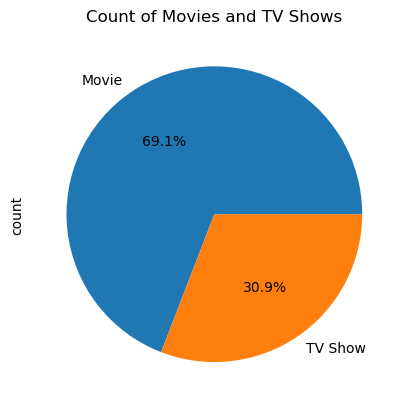

In [98]:
# Create a pie chart showing the distribution of content types (Movies vs TV Shows)
netflix_data_copy['type'].value_counts().plot.pie(autopct='%1.1f%%')
# Add a title to the pie chart
plt.title("Count of Movies and TV Shows")
# Display the pie chart
plt.show()

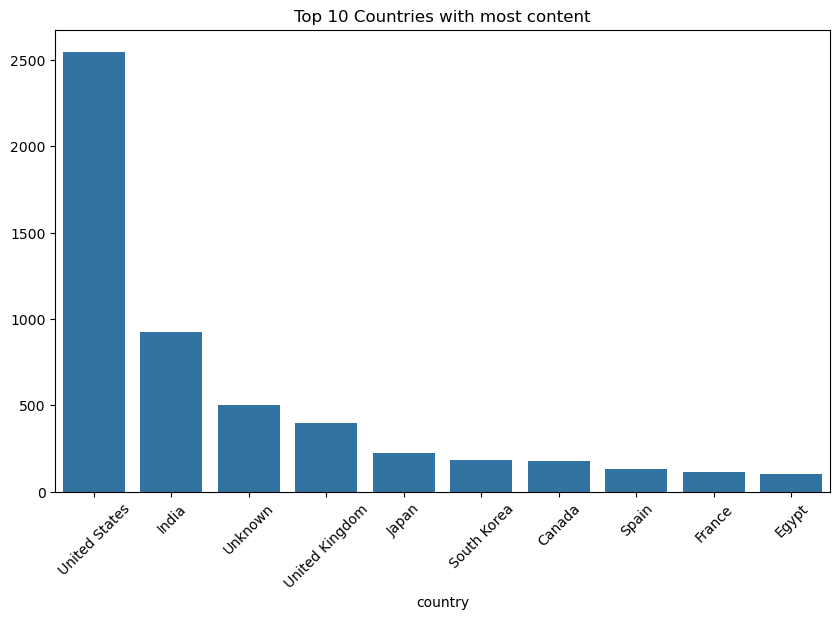

In [99]:
# Get the top 10 countries with the most content in the Netflix dataset
top_countries = netflix_data_copy['country'].value_counts().head(10)

# Create a figure with specified size
plt.figure(figsize=(10, 6))

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Set the title for the plot
plt.title("Top 10 Countries with most content")

# Create a bar plot showing countries on x-axis and their content count on y-axis
sns.barplot(x=top_countries.index, y=top_countries.values)

# Display the plot
plt.show()

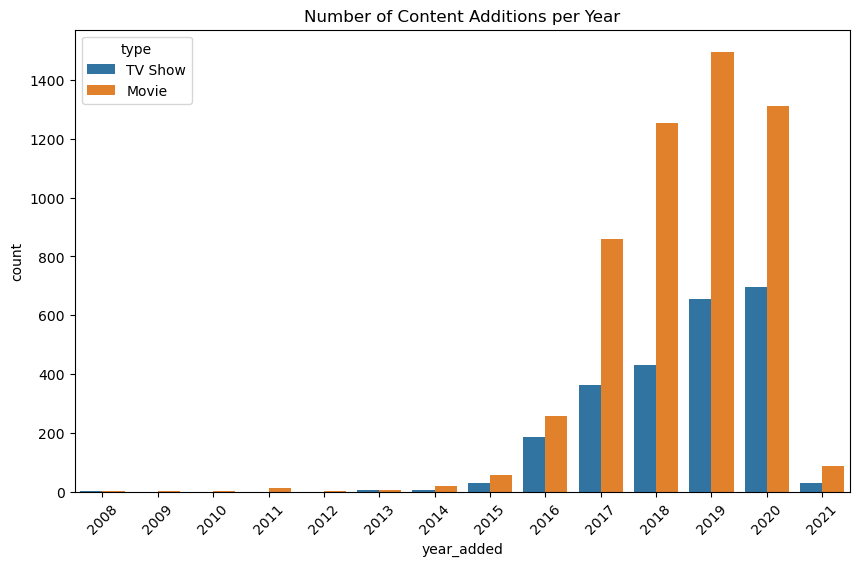

In [100]:
# Create a figure with specified size (10 inches width, 6 inches height)
plt.figure(figsize=(10,6))
# Create a count plot showing the distribution of content by year_added, colored by content type
sns.countplot(data=netflix_data_copy,x="year_added",hue='type')
# Add a title to the plot
plt.title("Number of Content Additions per Year")
# Rotate x-axis labels by 45 degrees to prevent overlap
plt.xticks(rotation=45)
# Display the plot
plt.show()

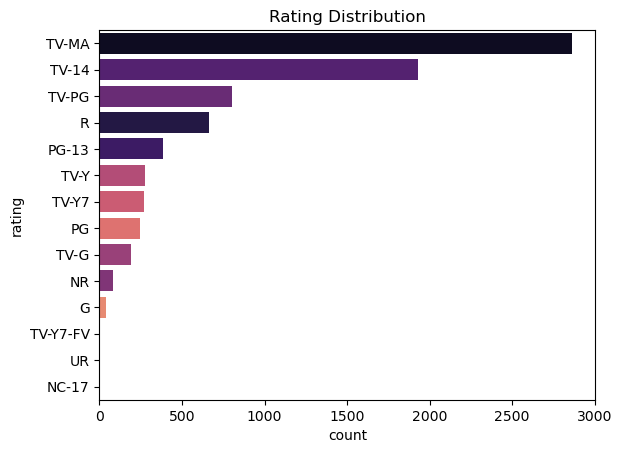

In [89]:
sns.countplot(data=netflix_data_copy,y='rating',hue="rating",order=netflix_data_copy['rating'].value_counts().index,palette='magma')
plt.title("Rating Distribution")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_5224\2682696293.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values,y=top_genres.index,palette='viridis')


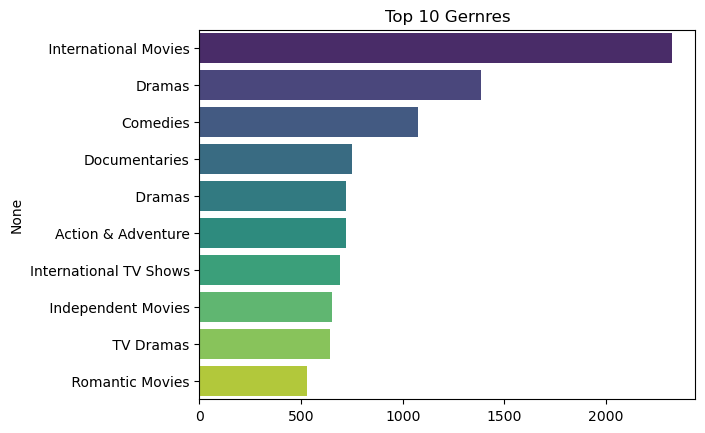

In [101]:
# Split the "listed_in" column by comma and stack the results to get individual genres
genres=netflix_data_copy["listed_in"].str.split(",",expand=True).stack()

# Count the frequency of each genre and get the top 10
top_genres=genres.value_counts().head(10)

# Create a horizontal bar plot of the top 10 genres
sns.barplot(x=top_genres.values,y=top_genres.index,palette='viridis')

# Add a title to the plot
plt.title("Top 10 Gernres")

# Display the plot
plt.show()

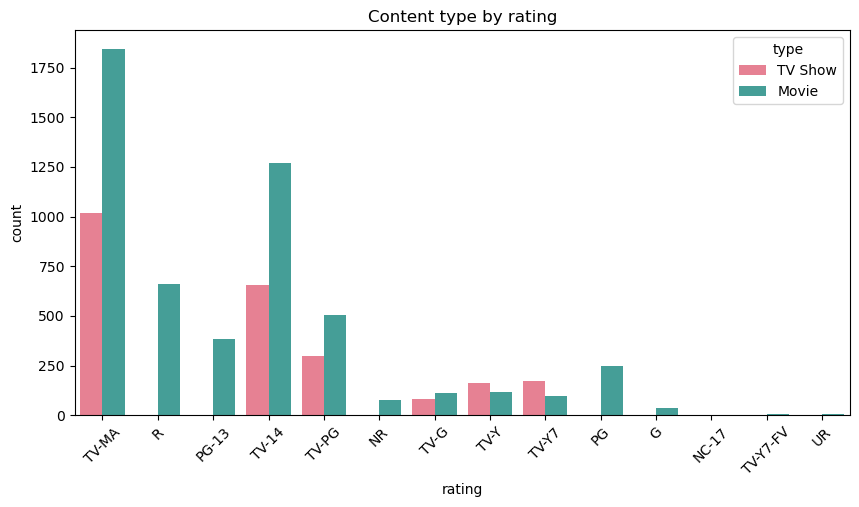

In [102]:
# Create a figure with specified size (10x5 inches)
plt.figure(figsize=(10,5))
# Create a count plot showing the distribution of ratings, separated by content type
# 'husl' palette provides distinct colors for better visualization
sns.countplot(data=netflix_data_copy, x='rating', hue='type', palette='husl')
# Add a title to the plot
plt.title("Content type by rating")
# Rotate x-axis labels by 45 degrees to prevent overlap
plt.xticks(rotation=45)
# Display the plot
plt.show()

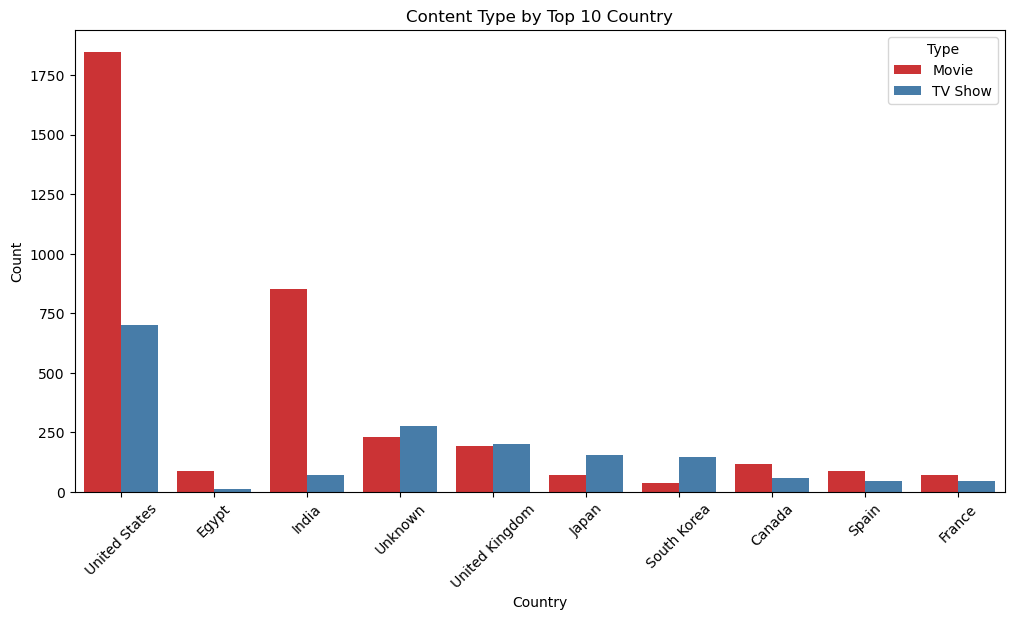

In [92]:
#bar chart for content type by top 10 country
top_countries=netflix_data_copy['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
top_countries_data=netflix_data_copy[netflix_data_copy['country'].isin(top_countries.index)]
sns.countplot(data=top_countries_data,x='country',hue='type',palette='Set1')
plt.title("Content Type by Top 10 Country")
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

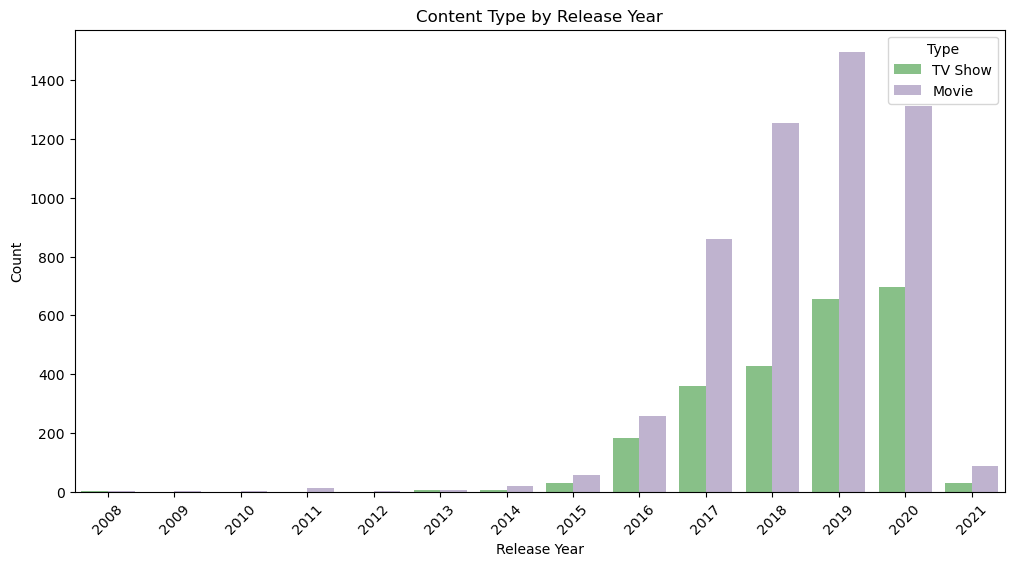

In [93]:
# bar chart for content type by release year
plt.figure(figsize=(12,6))
sns.countplot(data=netflix_data_copy,x='year_added',hue='type',palette='Accent')
plt.title("Content Type by Release Year")
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()
           

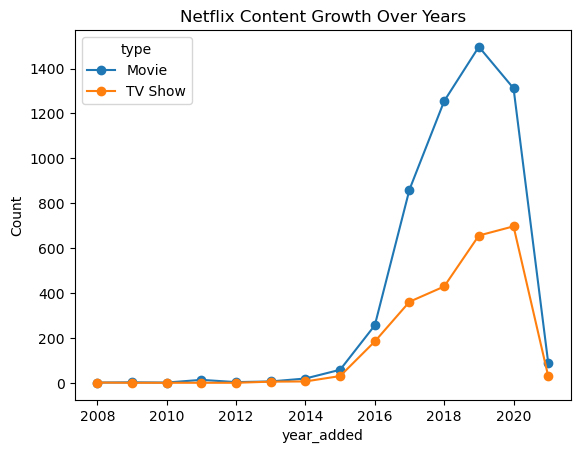

In [94]:
# line chart for netflix content growth over years
df_year_type=netflix_data_copy.groupby(['year_added','type']).size().unstack().fillna(0)
df_year_type.plot(kind='line',marker='o')
plt.title("Netflix Content Growth Over Years")
plt.ylabel("Count")
plt.show()

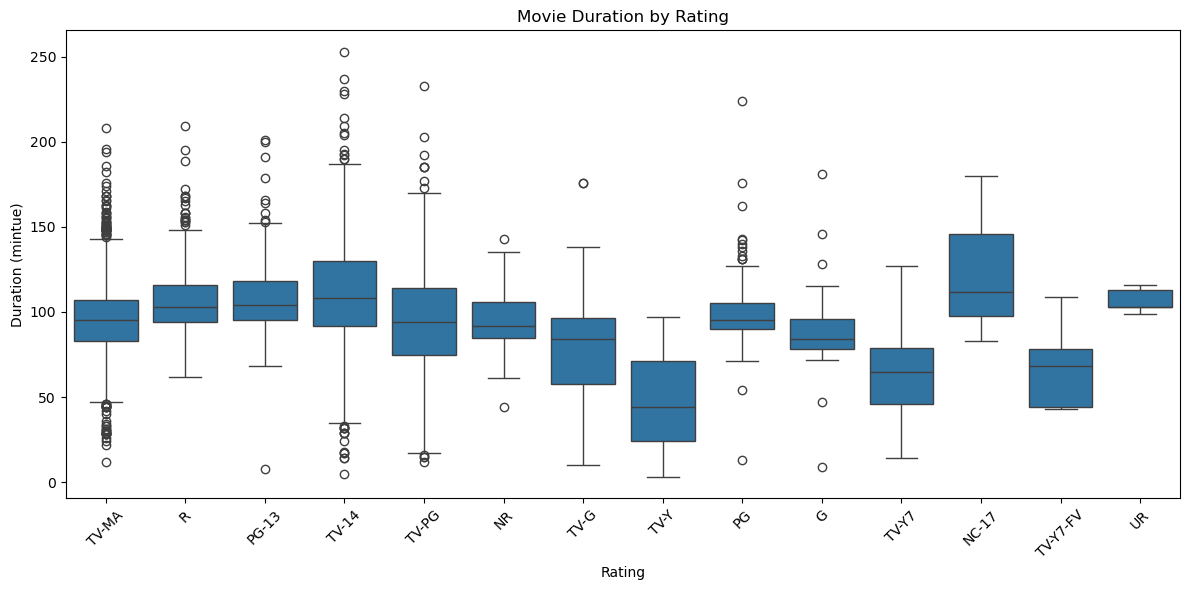

In [95]:
# box plot for movie duration by rating
movies=netflix_data_copy[netflix_data_copy['type']=='Movie'].copy()
movies['duration_int']=movies['duration'].str.extract('(\d+)').astype(float)
movies=movies[(movies['duration_int']<300) & (movies['duration_int']>0)]
plt.figure(figsize=(12,6))
sns.boxplot(data=movies,x='rating',y='duration_int')
plt.title('Movie Duration by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration (mintue)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()